In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS, get_trained_agent
from sac.trainer import HockeyTrainer, SCORE_REWARD, DEFAULT_REWARD
from sac.tournament import PooledTournament

In [ ]:
params = SB3_PARAMS
hidden_sizes = [256, 256]
params["alpha"] = 0.003
params["hidden_sizes"] = hidden_sizes

In [3]:
random_seed = 0

In [4]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [5]:
filepath = f"./results/adaptive-{random_seed}"

In [6]:
trainer = HockeyTrainer(params, reward_func=DEFAULT_REWARD)
weak_opponent = h_env.BasicOpponent(weak=True)
strong_opponent = h_env.BasicOpponent(weak=False)

In [7]:
trainer.load("./agents/strongcont-0", episode=5500)

In [8]:
tournament = PooledTournament(seed=random_seed)
tournament.add_agent(weak_opponent)
tournament.add_agent(strong_opponent)

In [9]:
agent_paths = [
    "./agents/reward-0-5000.pth",
    "./agents/continue-0-10000.pth",
    "./agents/selfplay-0-5000.pth",
    "./agents/strong-0-7000.pth",
    "./agents/strongcont-0-5000.pth",
    # "./agents/strongcont-0-5500.pth",
]
tournament.add_agent(weak_opponent)
tournament.add_agent(strong_opponent)
for agent_path in agent_paths:
    new_agent = get_trained_agent(agent_path)
    tournament.add_agent(new_agent)

In [10]:
trainer.warmup(256)

In [11]:
max_timesteps = 500
new_episodes = 500
log_interval = 20
train_interval = 20

In [25]:
def evaluate_agent(trainer, opponent, n=100):
    rewards, scores = trainer.evaluate(opponent, n, render=False)
    # print("Avg reward:",np.mean(rewards))
    print("Winrate:",0.5 * (np.mean(scores)+1))
    print("Winrate (no ties):", np.mean(np.asarray(scores) == 1))

In [13]:
def add_agent(trainer, tournament, params):
    new_agent = trainer.create_agent(params)
    agent_state = trainer.agent.state()
    new_agent.restore_state(agent_state)
    tournament.add_agent(new_agent)

In [14]:
for i in range(20):
    trainer.train(tournament, new_episodes, train_interval, log_interval, max_timesteps)
    evaluate_agent(trainer, weak_opponent)
    evaluate_agent(trainer, strong_opponent)
    trainer.save_agent(filepath)
    add_agent(trainer, tournament, params)

    20: Reward:    0.872 Winrate:    0.625
    40: Reward:    1.325 Winrate:    0.700
    60: Reward:    1.863 Winrate:    0.700
    80: Reward:    2.591 Winrate:    0.750
   100: Reward:    0.000 Winrate:    0.650
   120: Reward:   -4.247 Winrate:    0.450
   140: Reward:   -5.212 Winrate:    0.425
   160: Reward:    0.306 Winrate:    0.650
   180: Reward:    0.249 Winrate:    0.650
   200: Reward:    2.091 Winrate:    0.725
   220: Reward:    0.144 Winrate:    0.625
   240: Reward:    4.759 Winrate:    0.800
   260: Reward:   -2.212 Winrate:    0.550
   280: Reward:    1.350 Winrate:    0.675
   300: Reward:    0.525 Winrate:    0.650
   320: Reward:    4.739 Winrate:    0.825
   340: Reward:    1.829 Winrate:    0.700
   360: Reward:   -0.278 Winrate:    0.625
   380: Reward:    1.347 Winrate:    0.675
   400: Reward:    0.378 Winrate:    0.625
   420: Reward:    2.526 Winrate:    0.750
   440: Reward:    0.110 Winrate:    0.625
   460: Reward:    2.798 Winrate:    0.725
   480: Rew

In [15]:
trainer.evaluate(weak_opponent, render=True)

([8.982531526944094,
  9.883917770391033,
  -3.471934135599911,
  -5.126893296992131,
  9.21660854973723],
 [1, 1, 0, 0, 1])

In [16]:
trainer.evaluate(strong_opponent, render=True)

([7.473680503458752,
  9.66813170478957,
  8.933344866383347,
  -15.700173348135603,
  10.0],
 [1, 1, 1, -1, 1])

In [17]:
trainer.reset()

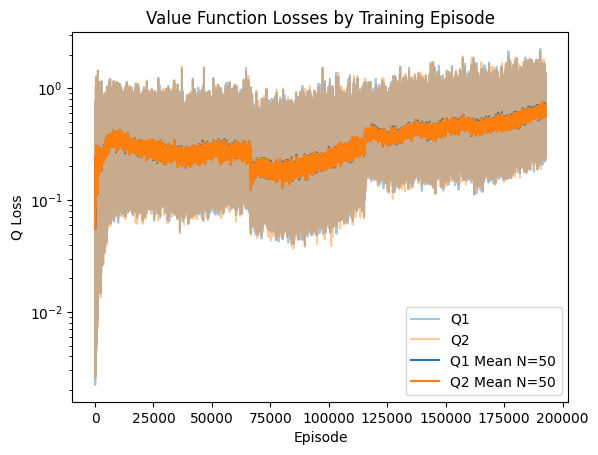

In [18]:
q_losses = np.stack([trainer.logs["Q1_loss"], trainer.logs["Q2_loss"]]).T
plot_q(q_losses, "./results")

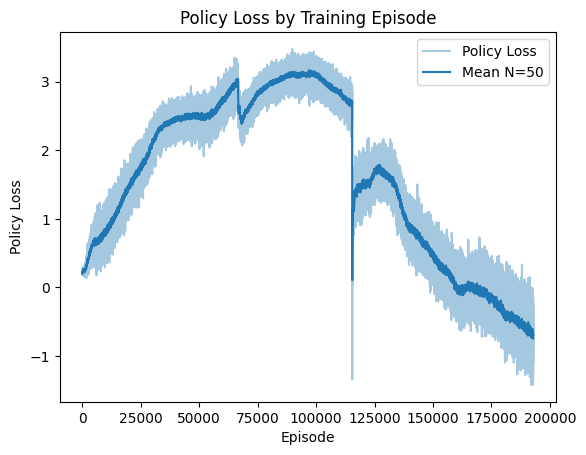

In [19]:
plot_policy_loss(trainer.logs["Policy_loss"], "./results")

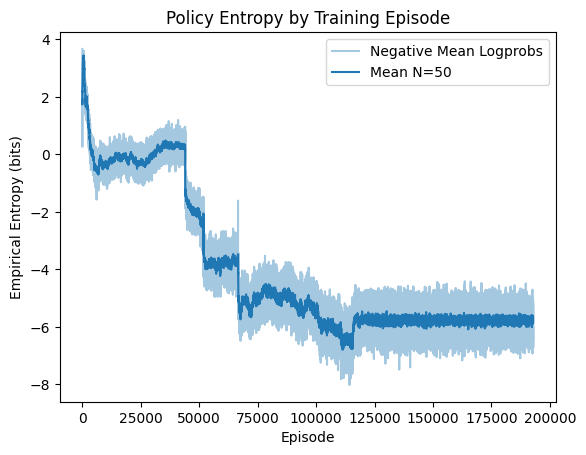

In [20]:
plot_entropy(np.asarray(trainer.logs["Logprobs"]), "./results")

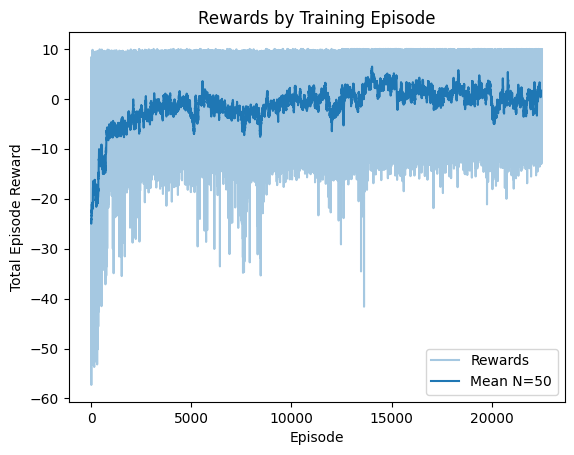

In [21]:
plot_rewards(trainer.logs["Rewards"], "./results")

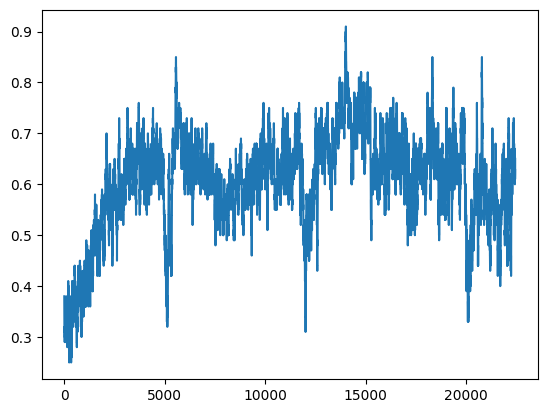

In [22]:
plt.plot(running_mean(0.5*(np.asarray(trainer.logs["Scores"])+1), 50))

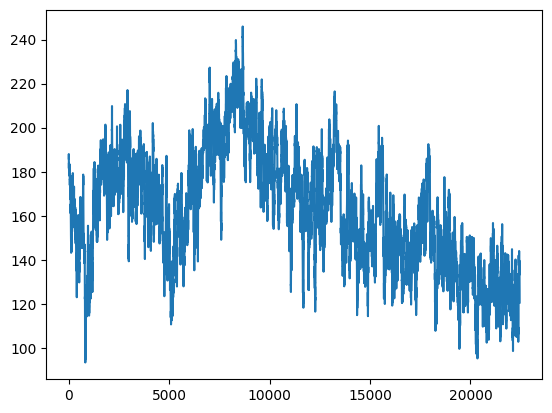

In [23]:
plt.plot(running_mean(trainer.logs["Lengths"], 50))

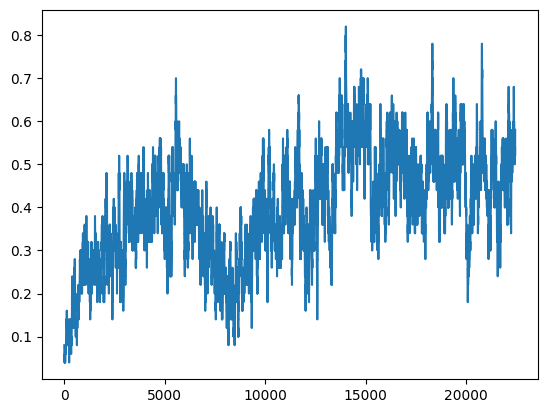

In [24]:
plt.plot(running_mean(np.asarray(trainer.logs["Scores"]) == 1, 50))